# 04 - 模型评估：如何知道模型真的有效

> 配套教程：`03_machine_learning/04_model_evaluation.py`

模型评估的目标不是得到一个好看的数字，而是回答：“这个模型在未来没见过的数据上是否可靠？”

## 学习目标

| 能力 | 具体表现 |
|------|----------|
| 正确划分数据 | 区分训练集、验证集、测试集的用途 |
| 避免数据泄露 | 知道标准化、特征选择为什么只能在训练集上 fit |
| 使用交叉验证 | 能解释均值和标准差的含义 |
| 选择分类指标 | 能区分 Accuracy、Precision、Recall、F1 |
| 调整阈值 | 能根据业务成本改变分类阈值 |
| 诊断拟合状态 | 能通过训练/测试差距判断欠拟合和过拟合 |

In [1]:
# 环境设置
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    print("Linux 可安装：sudo apt-get install fonts-noto-cjk 或 fonts-wqy-zenhei")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
print("环境准备完毕")

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score,
)
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

Matplotlib 中文字体: Noto Sans CJK JP
环境准备完毕


## 1. 训练集、验证集、测试集分别做什么

- **训练集**：模型用它学习参数。
- **验证集**：我们用它选择超参数，例如学习率、树深度、正则化强度。
- **测试集**：最终只用一次，模拟未来新数据表现。

关键原则：测试集不能参与模型选择。否则测试集会被“调参调熟”，评估会偏乐观。

### 评估的核心问题：泛化

训练集表现好，只说明模型会处理见过的数据；我们真正关心的是它能否处理未来没见过的数据，这叫泛化能力。

很多初学者会犯的错误是：看到训练准确率很高就觉得模型很好。但如果模型只是记住训练样本，它在新数据上可能很差。

因此模型评估的基本思想是：用训练过程没见过的数据来模拟未来数据。

In [2]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

print(f"总数据: {len(X)}")
print(f"训练集: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"验证集: {len(X_val)} ({len(X_val)/len(X):.0%})")
print(f"测试集: {len(X_test)} ({len(X_test)/len(X):.0%})")

总数据: 1000
训练集: 600 (60%)
验证集: 200 (20%)
测试集: 200 (20%)


## 2. 数据泄露：评估中最隐蔽的问题

数据泄露指模型训练过程中看到了不该看到的信息。常见例子：

- 先对全部数据标准化，再划分训练/测试。
- 用全部数据挑选特征，再训练。
- 反复看测试集分数并据此调参。

正确做法：所有会从数据中学习参数的预处理步骤，都只在训练集上 `fit`，再对验证集和测试集 `transform`。

In [3]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_norm, y_train)

print(f"验证集准确率: {model.score(X_val_norm, y_val):.4f}")
print(f"测试集准确率: {model.score(X_test_norm, y_test):.4f}")
print("标准化均值来自训练集，前三个均值:", scaler.mean_[:3].round(3))

验证集准确率: 0.8000
测试集准确率: 0.8300
标准化均值来自训练集，前三个均值: [ 0.535 -0.014 -0.022]


### Pipeline 为什么重要

在真实项目中，模型通常不是单独存在的，而是一串步骤：缺失值处理、标准化、特征选择、模型训练。

如果你手动分开写，很容易不小心在全量数据上 fit 预处理器，造成数据泄露。`Pipeline` 的好处是把预处理和模型绑在一起，在交叉验证中每一折都会只用当前训练折 fit 预处理器。

所以，在涉及交叉验证和预处理时，推荐使用：

```python
pipeline = make_pipeline(StandardScaler(), LogisticRegression())
cross_val_score(pipeline, X, y, cv=5)
```

这比先 `scaler.fit_transform(X)` 再交叉验证更安全。

## 3. 交叉验证：减少一次划分带来的偶然性

如果数据不多，单次训练/验证划分可能不稳定。K 折交叉验证：

1. 把训练数据分成 $K$ 份。
2. 每次用一份验证，其余训练。
3. 重复 $K$ 次，得到 $K$ 个分数。
4. 用平均值衡量整体表现，用标准差衡量稳定性。

In [4]:
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
scores = cross_val_score(pipeline, X_train_full, y_train_full, cv=5)
print("5 折交叉验证分数:", scores.round(4))
print(f"平均: {scores.mean():.4f} ± {scores.std():.4f}")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_shuffled = cross_val_score(pipeline, X_train_full, y_train_full, cv=kfold)
print("打乱后的 5 折分数:", scores_shuffled.round(4))

5 折交叉验证分数: [0.8188 0.8312 0.8562 0.8125 0.7938]
平均: 0.8225 ± 0.0208
打乱后的 5 折分数: [0.7688 0.7938 0.8188 0.8562 0.825 ]


## 4. Accuracy 为什么可能骗人

如果 95% 样本都是负类，一个永远预测负类的模型也能有 95% Accuracy，但它完全找不到正类。

混淆矩阵：

|  | 预测负 | 预测正 |
|---|---:|---:|
| 实际负 | TN | FP |
| 实际正 | FN | TP |

指标：

$$Precision=\frac{TP}{TP+FP}$$

$$Recall=\frac{TP}{TP+FN}$$

$$F1=\frac{2\cdot Precision\cdot Recall}{Precision+Recall}$$

In [5]:
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=12,
    n_informative=5,
    weights=[0.94, 0.06],
    flip_y=0.01,
    random_state=42,
)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train_i, y_train_i)
y_pred = clf.predict(X_test_i)

print(f"正类比例: {y_imb.mean():.2%}")
print(f"Accuracy : {accuracy_score(y_test_i, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_i, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test_i, y_pred):.4f}")
print(f"F1       : {f1_score(y_test_i, y_pred):.4f}")
print("\n混淆矩阵 [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test_i, y_pred))

正类比例: 6.33%
Accuracy : 0.9528
Precision: 0.8000
Recall   : 0.3478
F1       : 0.4848

混淆矩阵 [[TN, FP], [FN, TP]]:
[[335   2]
 [ 15   8]]


### 指标选择的业务视角

不同错误的代价不同，指标选择也应不同：

| 场景 | 更怕什么 | 更关注 |
|------|----------|--------|
| 疾病筛查 | 漏掉真正患病的人 FN | Recall |
| 垃圾邮件过滤 | 正常邮件被误杀 FP | Precision |
| 欺诈检测初筛 | 漏掉欺诈 FN，但人工复核能力有限 | Precision 和 Recall 平衡 |
| 推荐系统点击预测 | 排序质量和概率校准 | AUC、LogLoss、校准曲线 |

不要脱离场景讨论“哪个指标最好”。指标是业务目标的数学代理。

In [6]:
y_pred_dumb = np.zeros_like(y_test_i)
print("永远预测负类的模型：")
print(f"Accuracy : {accuracy_score(y_test_i, y_pred_dumb):.4f}")
print(f"Recall   : {recall_score(y_test_i, y_pred_dumb, zero_division=0):.4f}")
print("\n对比模型完整报告：")
print(classification_report(y_test_i, y_pred, target_names=["负类", "正类"]))

永远预测负类的模型：
Accuracy : 0.9361
Recall   : 0.0000

对比模型完整报告：
              precision    recall  f1-score   support

          负类       0.96      0.99      0.98       337
          正类       0.80      0.35      0.48        23

    accuracy                           0.95       360
   macro avg       0.88      0.67      0.73       360
weighted avg       0.95      0.95      0.94       360



## 5. 阈值调整：指标背后是业务取舍

逻辑回归默认阈值是 0.5，但阈值越低，模型越容易预测正类：

- Recall 往往上升，因为更多真实正类被找出来。
- Precision 可能下降，因为也会带来更多误报。

没有“永远正确”的阈值，只有更符合业务成本的阈值。

In [7]:
y_score = clf.predict_proba(X_test_i)[:, 1]

print(f"{'阈值':<8} {'Precision':<12} {'Recall':<12} {'F1':<10} {'预测正类数'}")
print("-" * 58)
for threshold in [0.1, 0.2, 0.3, 0.5, 0.7]:
    pred = (y_score >= threshold).astype(int)
    print(
        f"{threshold:<8.1f} "
        f"{precision_score(y_test_i, pred, zero_division=0):<12.4f} "
        f"{recall_score(y_test_i, pred):<12.4f} "
        f"{f1_score(y_test_i, pred):<10.4f} "
        f"{pred.sum()}"
    )

阈值       Precision    Recall       F1         预测正类数
----------------------------------------------------------
0.1      0.2833       0.7391       0.4096     60
0.2      0.4516       0.6087       0.5185     31
0.3      0.5652       0.5652       0.5652     23
0.5      0.8000       0.3478       0.4848     10
0.7      1.0000       0.3478       0.5161     8


## 6. ROC 曲线与 PR 曲线

ROC 曲线看的是不同阈值下：

- True Positive Rate，也就是 Recall。
- False Positive Rate，也就是负类中被误报为正类的比例。

PR 曲线看的是 Precision 和 Recall 的权衡。

对不平衡数据，PR 曲线通常更有信息量，因为它更关注少数正类的识别质量。

### ROC-AUC 和 PR-AUC 的直觉区别

ROC-AUC 衡量模型把正类排在负类前面的能力。它对类别比例相对不敏感，因此在极度不平衡时，有时看起来仍然很好。

PR 曲线直接关注：当模型找出一批“可能为正”的样本时，其中有多少是真的正，以及真实正类找回了多少。对于少数类识别任务，PR 曲线通常更贴近业务感受。

经验规则：

- 类别比较平衡：Accuracy、ROC-AUC 都有参考价值。
- 正类很稀少：重点看 Precision、Recall、F1、PR-AUC。
- 输出概率要用于决策：还要检查概率校准。

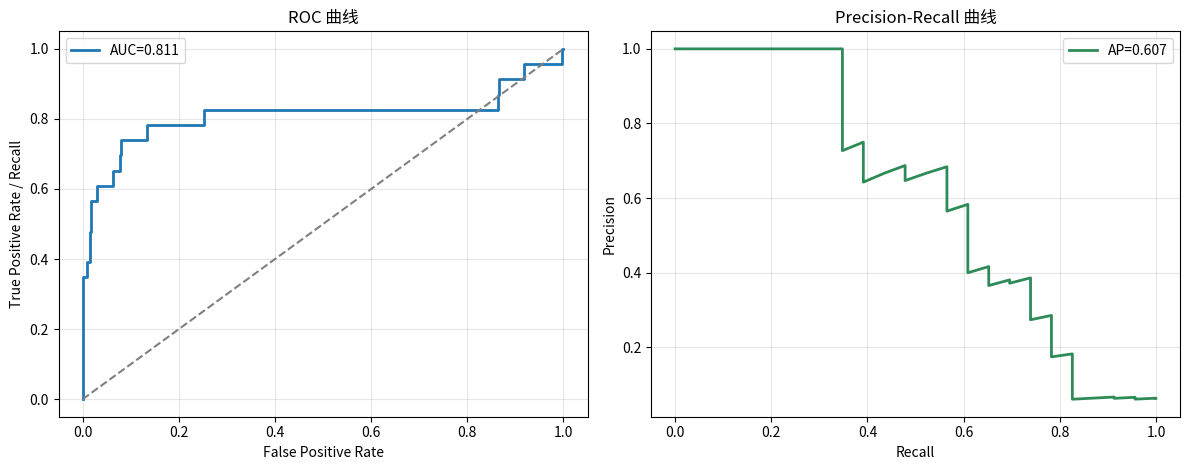

In [8]:
fpr, tpr, _ = roc_curve(y_test_i, y_score)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_i, y_score)
avg_precision = average_precision_score(y_test_i, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].set_title("ROC 曲线")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(recall, precision, linewidth=2, color="seagreen", label=f"AP={avg_precision:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall 曲线")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. 偏差-方差权衡：欠拟合和过拟合

可以用训练分数和测试分数的关系做初步诊断：

| 现象 | 可能问题 | 处理方向 |
|------|----------|----------|
| 训练差、测试也差 | 欠拟合，高偏差 | 换更复杂模型、增加特征 |
| 训练好、测试差 | 过拟合，高方差 | 正则化、剪枝、更多数据 |
| 训练好、测试也好 | 较合适 | 可以继续微调或部署前验证 |

决策树深度是观察这个问题的好例子。

树深度      训练准确率        测试准确率        诊断
--------------------------------------------------
1        0.7619       0.7556       欠拟合
2        0.8143       0.8056       较合适
3        0.8881       0.7889       较合适
5        0.9476       0.8056       过拟合
10       1.0000       0.8167       过拟合
无限       1.0000       0.8167       过拟合


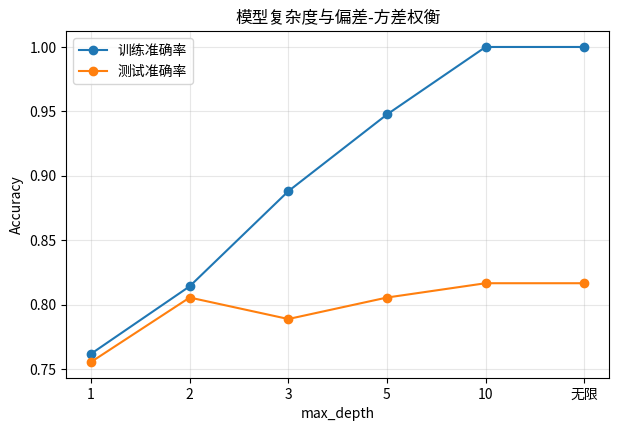

In [9]:
X_bv, y_bv = make_classification(n_samples=600, n_features=10, n_informative=5, random_state=42)
X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(X_bv, y_bv, test_size=0.3, random_state=42)

depths = [1, 2, 3, 5, 10, None]
train_scores, test_scores = [], []
print(f"{'树深度':<8} {'训练准确率':<12} {'测试准确率':<12} {'诊断'}")
print("-" * 50)
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train_bv, y_train_bv)
    train_acc = tree.score(X_train_bv, y_train_bv)
    test_acc = tree.score(X_test_bv, y_test_bv)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    gap = train_acc - test_acc
    diagnosis = "欠拟合" if train_acc < 0.80 else ("过拟合" if gap > 0.12 else "较合适")
    depth_label = str(depth) if depth is not None else "无限"
    print(f"{depth_label:<8} {train_acc:<12.4f} {test_acc:<12.4f} {diagnosis}")

labels = [str(d) if d is not None else "无限" for d in depths]
plt.figure(figsize=(7, 4.5))
plt.plot(labels, train_scores, marker="o", label="训练准确率")
plt.plot(labels, test_scores, marker="o", label="测试准确率")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("模型复杂度与偏差-方差权衡")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. 学习曲线：更多数据是否有帮助

学习曲线展示训练样本数增加时，训练分数和验证分数如何变化。

- 两条曲线都低：模型可能太简单。
- 训练高、验证低：模型可能过拟合，更多数据可能有帮助。
- 两条曲线接近且高：模型比较稳定。

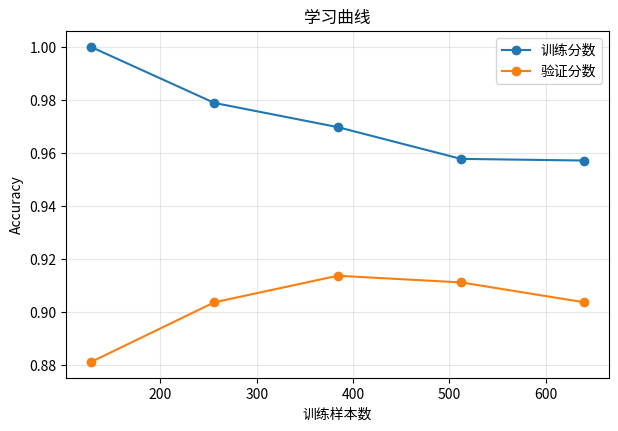

训练样本数: [128 256 384 512 640]
验证分数均值: [0.8812 0.9038 0.9138 0.9112 0.9038]


In [10]:
rf_model = RandomForestClassifier(n_estimators=80, max_depth=5, random_state=42)
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    rf_model,
    X_train_full,
    y_train_full,
    cv=5,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="accuracy",
)

train_mean = train_scores_lc.mean(axis=1)
val_mean = val_scores_lc.mean(axis=1)

plt.figure(figsize=(7, 4.5))
plt.plot(train_sizes, train_mean, marker="o", label="训练分数")
plt.plot(train_sizes, val_mean, marker="o", label="验证分数")
plt.xlabel("训练样本数")
plt.ylabel("Accuracy")
plt.title("学习曲线")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("训练样本数:", train_sizes)
print("验证分数均值:", val_mean.round(4))

## 9. 总结与检查题

| 知识点 | 初学者应该记住 |
|--------|----------------|
| 数据划分 | 测试集只用于最终评估 |
| 数据泄露 | 预处理只能在训练集上 fit |
| 交叉验证 | 平均值看表现，标准差看稳定性 |
| Accuracy | 类别平衡时直观，不平衡时可能误导 |
| Precision | 预测为正的样本中有多少真的正 |
| Recall | 真实正类中有多少被找出来 |
| F1 | Precision 和 Recall 的折中 |
| 偏差-方差 | 通过训练/测试差距诊断拟合状态 |

**检查题**：

1. 为什么测试集不能反复用来调参？
2. 标准化为什么要先划分数据，再在训练集上 `fit`？
3. 一个模型 Accuracy 很高但 Recall 为 0，说明什么？
4. 阈值降低时，Precision 和 Recall 通常怎么变化？
5. 训练准确率 100%、测试准确率一般，应该优先怀疑什么？

## 10. 模型评估工作流

一个稳妥的评估流程可以这样做：

1. **先划分测试集**：测试集锁起来，不参与调参。
2. **构建 Pipeline**：把预处理和模型放在一起。
3. **用交叉验证选模型**：比较多个模型或超参数的平均表现和稳定性。
4. **根据业务选指标**：类别不平衡时不要只看 Accuracy。
5. **调阈值**：用验证集选择符合业务成本的阈值。
6. **最终测试**：只在最后用测试集报告一次结果。
7. **上线后监控**：真实数据分布可能变化，评估不是一次性工作。

### 本节最小掌握清单

- 能说出训练集、验证集、测试集分别用于什么。
- 能解释为什么先标准化再划分数据是潜在数据泄露。
- 能根据混淆矩阵手算 Precision、Recall、F1。
- 能说明不平衡数据下 Accuracy 为什么可能骗人。
- 能用训练分数和测试分数差距判断欠拟合/过拟合。

## 11. 评估报告应该包含什么

一个可靠的模型评估报告，不应该只有一个分数。建议至少包含：

1. **数据划分方式**：训练/验证/测试比例，是否分层抽样。
2. **预处理流程**：标准化、缺失值处理、特征选择是否只在训练集上 fit。
3. **主要指标**：根据任务选择 Accuracy、Precision、Recall、F1、AUC 或 PR-AUC。
4. **混淆矩阵**：让错误类型一目了然。
5. **阈值说明**：如果不是默认 0.5，要说明选择依据。
6. **交叉验证结果**：平均值和标准差。
7. **错误分析**：模型经常错在哪些样本上。
8. **风险说明**：数据量、类别不平衡、分布漂移等限制。

这能避免“分数很好但不可用”的情况。

## 12. 常见评估错误清单

- **用训练集当测试集**：得到的是记忆能力，不是泛化能力。
- **测试集参与调参**：测试集会被反复优化，最终分数偏乐观。
- **先预处理全量数据再切分**：标准化、缺失值填充、特征选择都可能泄露信息。
- **类别不平衡时只看 Accuracy**：多数类模型也能得到高准确率。
- **只看平均指标**：不同子群体上可能表现差异很大。
- **忽略阈值**：概率模型的默认阈值不一定符合业务成本。
- **忽略数据漂移**：上线后的数据分布可能与训练时不同。

评估不是最后一步，而是贯穿建模全流程的质量控制。

## 13. 面向初学者的指标选择指南

如果你不知道该用哪个指标，可以先问三个问题：

1. **类别是否平衡？**
   - 平衡：Accuracy 可以作为起点。
   - 不平衡：优先看 Precision、Recall、F1、PR-AUC。

2. **哪种错误更贵？**
   - FP 更贵：关注 Precision。
   - FN 更贵：关注 Recall。
   - 两者都重要：关注 F1 或根据业务成本自定义指标。

3. **模型输出概率是否会用于排序或决策？**
   - 如果会，要看 ROC/PR 曲线和阈值表现。
   - 如果概率本身要解释成风险，还要进一步做概率校准检查。

掌握这个决策流程，比死记指标公式更重要。